In [1]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import joblib
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import(
        mean_absolute_error,
        mean_squared_error,
        r2_score

   )
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import cross_val_score
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.ensemble import (
        GradientBoostingRegressor,
        AdaBoostRegressor,

    )
    import os
    from scipy.stats import f_oneway
    import warnings
    warnings.filterwarnings("ignore")
    print("All libraries imported successfully.")
except ImportError as e:
    print(f"Error importing libraries: {e}")


All libraries imported successfully.


In [2]:
train_X_processed, test_X_processed, y_train, y_test = joblib.load(
    r"C:\Users\akash\OneDrive\Documents\ML project\Used Car Price Estimation\notebook\model\preprocessed_data.pkl"
)

In [3]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "LinearRegression": LinearRegression(),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [4]:
model_score =-0
model_name = None
for key,items in models.items():
    print(f'\nModel Name {key}')
    items.fit(train_X_processed,y_train)
    y_prd2 = items.predict(test_X_processed)

    mae = mean_absolute_error(y_test, y_prd2)
    mse = mean_squared_error(y_test, y_prd2)
    r2 = r2_score(y_test, y_prd2)
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print(f'\nModel Score')
    
    train_models = items.score(train_X_processed,y_train)
    test_models = items.score(test_X_processed,y_test)
    print(f'model Train Score {train_models}')
    print(f'model Test Score {test_models}')

    # Linear Regression
    cv_scores = cross_val_score(items, train_X_processed, y_train, cv=5, scoring="r2")

    print("\nCross Validation Scores:", cv_scores)
    print("Average R2 Score:", cv_scores.mean())
    print('------------------------------------------------------------------------------------')

    if r2 > model_score:
        model_score=r2
        model_name=items


    


Model Name RandomForest
MAE: 852.4908156486363
MSE: 1141512.522755919
R2 Score: 0.8565131888538976

Model Score
model Train Score 0.913576307464165
model Test Score 0.8565131888538976

Cross Validation Scores: [0.84977193 0.85413661 0.85312388 0.85645888 0.84376758]
Average R2 Score: 0.8514517767095668
------------------------------------------------------------------------------------

Model Name DecisionTree
MAE: 990.2310352384031
MSE: 1575605.0464508922
R2 Score: 0.8019482579173722

Model Score
model Train Score 0.8980830485506835
model Test Score 0.8019482579173722

Cross Validation Scores: [0.80371624 0.79335462 0.79140903 0.8020934  0.79125176]
Average R2 Score: 0.7963650136958444
------------------------------------------------------------------------------------

Model Name LinearRegression
MAE: 790.8005398553188
MSE: 981328.4815661978
R2 Score: 0.8766481385882366

Model Score
model Train Score 0.8709195049528506
model Test Score 0.8766481385882366

Cross Validation Scores: [0

In [5]:
print(model_name)
print(model_score)

LinearRegression()
0.8766481385882366


In [7]:
model_name.fit(train_X_processed,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[1247.74, 606.26,1927.14,..., -0.5 , 17.38, -17.38]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7912
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(24)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](30,)","[91.12,90.12,89.56,..., 0. , 0. , 0. ]"


In [8]:
y_prd = model_name.predict(test_X_processed)

In [9]:
data_compare = pd.DataFrame({
    'Actaual Pradict':y_test,
    'Prdicat Value':y_prd
})
print(data_compare)

      Actaual Pradict  Prdicat Value
6252         12772.12   12131.611536
4684          6177.69    4688.806264
1731          6850.02    7069.833758
4742          3373.18    3576.126035
4521          7314.85    8034.572319
...               ...            ...
6412          6626.06    6292.141953
8285          5447.34    5607.628089
7853         13146.23   13341.812374
1095         11408.78    9613.893229
6929          4974.73    3323.643557

[2000 rows x 2 columns]


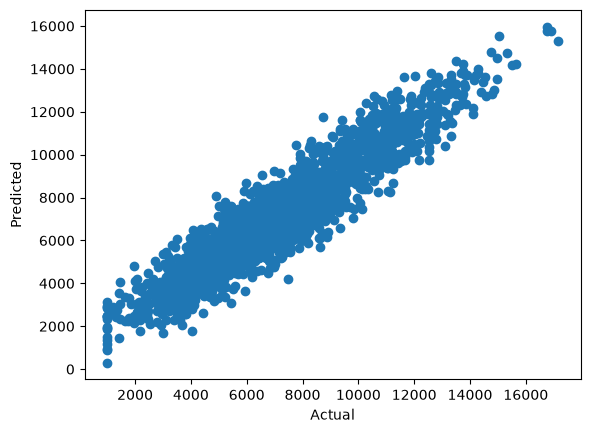

In [13]:
os.mkdir("actual_vs_predicted_graph")
plt.Figure(figsize=(10,5))
plt.scatter(y_test, y_prd)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.savefig("actual_vs_predicted_graph/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
joblib.dump(model_name,r"C:\Users\akash\OneDrive\Documents\ML project\Used Car Price Estimation\notebook\model/model.pkl")

['C:\\Users\\akash\\OneDrive\\Documents\\ML project\\Used Car Price Estimation\\notebook\\model/model.pkl']